# Qiskit 01- Single Systems

In [2]:
import numpy as np
from qiskit import __version__
from qiskit.visualization import array_to_latex
print(__version__)

1.3.1


In [3]:
ket0 = np.array([[1],[0]])
ket1 = np.array([[0],[1]])

plus = ket0/np.sqrt(2) + ket1/np.sqrt(2)
minus = ket0/np.sqrt(2) - ket1/np.sqrt(2)
display(array_to_latex(plus))
display(array_to_latex(minus))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## States, measurements, and operations

### Defining and displaying state vectors

* Qiskit's `Statevector` class provides functionality for defining and manipulating quantum state vectors.
* The `Statevector` class includes a `draw` method for displaying state vectors in a variety of ways, including `text` for plain text, `latex` for rendered LaTeX, and `latex_source` for LaTeX code
* The `Statevector` class also includes the `is_valid` method, which checks to see if a given vector is a valid quantum state vector (i.e., that it has Euclidean norm equal to 1)

In [4]:
from qiskit.quantum_info import Statevector
ket0 = Statevector(ket0)
ket1 = Statevector(ket1)
plus = Statevector(plus)
minus = Statevector(minus)

display(plus.draw("text"))
display(plus.draw("latex"))
print(plus.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


In [ ]:
# 该方法检查给定向量是否为有效的量子态向量 （即，它的欧几里得范数是否等于 1）
u = Statevector([1 / np.sqrt(2), 1 / np.sqrt(2)])
w = Statevector([1 / 3, 2 / 3])
display(u.is_valid())
display(w.is_valid())

True

False

### Simulating measurements using Statevector

Next we will see one way that measurements of quantum states can be simulated in Qiskit, using the `measure` method from the `Statevector` class.
* Running the `measure` method simulates a standard `basis` measurement. It returns the `outcome of that measurement`, plus the `new quantum state vector of the system` after the measurement.

In [16]:
# 运行该方法 measure 可模拟标准基测量。它返回该测量的结果，以及测量后系统的新量子态向量。
# Prob(outcome is '0') = 1/2, state gets projected onto |0> 
# Prob(outcome is '1') = 1/2, state gets projected onto |1> 
display(plus.draw("latex"))
outcome, state = plus.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

<IPython.core.display.Latex object>

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

In [ ]:
# 在这两种情况下，∣0⟩ 和 ∣1⟩ 的替代项实际上等同于这些状态向量;
# 它们被称为等价于一个全局相位，因为一个等于另一个乘以单位圆上的复数。
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

* `Statevector` also comes with a `sample_counts` method that allows for the simulation of any number of measurements on the system, each time starting with a fresh copy of the state. 

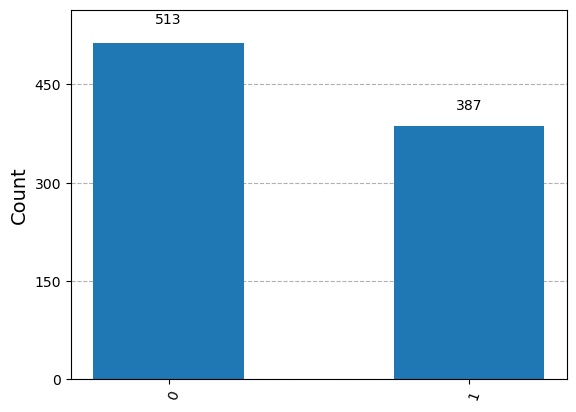

In [ ]:
from qiskit.visualization import plot_histogram
# 5/9 与 4/9 的概率
statistics = v.sample_counts(900)
plot_histogram(statistics)

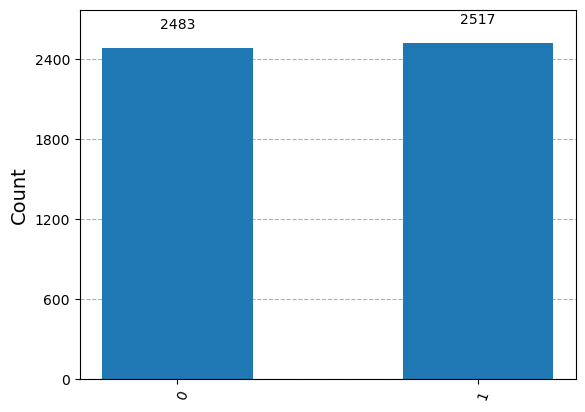

In [36]:
from qiskit.visualization import plot_histogram
# 1/2 的概率
statistics = plus.sample_counts(5000)
plot_histogram(statistics)

### Performing operations with `Operator` and `Statevector`

* Unitary operations can be defined in Qiskit using the `Operator` class, as in the example that follows.

In [39]:
# 可以在 Qiskit 中使用 Operator 类定义酉运算
from qiskit.quantum_info import Operator

X = Operator([[0, 1.0], [1.0, 0]])
Y = Operator([[0, -1.0j], [1.0j, 0]])
Z = Operator([[1.0, 0.0], [0.0, -1.0]])
H = Operator([[1 / np.sqrt(2), 1 / np.sqrt(2)], [1 / np.sqrt(2), -1 / np.sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / np.sqrt(2)]])

display(T.draw("latex"))
display(X.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
R = np.matmul(H,np.matmul(S,H))
print(R@R)
R = Operator(R)
display(R.draw("latex"))
print(np.matmul(R,R))

[[0.-2.46519033e-32j 1.+0.00000000e+00j]
 [1.+0.00000000e+00j 0.+2.46519033e-32j]]


<IPython.core.display.Latex object>

[[0.-2.46519033e-32j 1.+0.00000000e+00j]
 [1.+0.00000000e+00j 0.+2.46519033e-32j]]


* We can apply a unitary operation to a state vector using the `evolve` method.

In [40]:
# 使用方法 evolve 将酉运算应用于状态向量
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

### Looking ahead toward quantum circuits

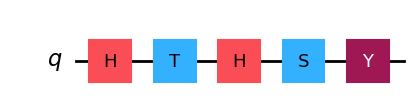

In [41]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

* 0 quantum state

In [43]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

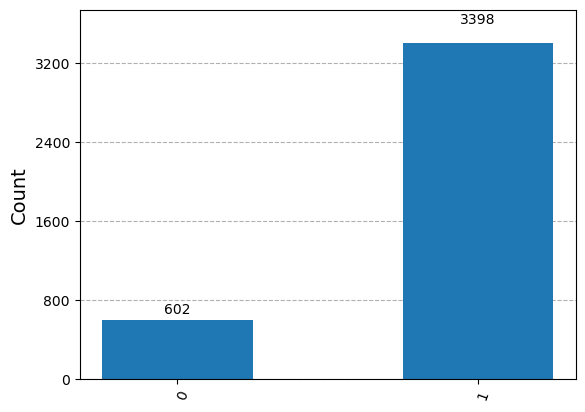

In [46]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))

* plus quantum state

In [42]:
plus = Statevector([1.0/np.sqrt(2), 1.0/np.sqrt(2)])
v = plus.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

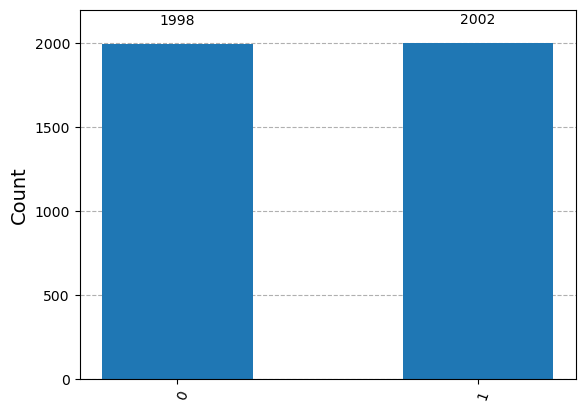

In [43]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))